# Categorical Encoding

In [82]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('K:/Data Science Internship/WEEK 4/datasets/customer_categorical_dataset.csv')
pd.set_option('display.float_format', '{:.4f}'.format)
df.head()


,Gender,City,Education_Level,Membership_Type,Payment_Method,Age,Annual_Income,Spending_Score
0,Male,Chennai,High School,Platinum,Net Banking,45,1134550,16
1,Female,Delhi,Master,Silver,UPI,22,782111,24
2,Male,Delhi,Master,Basic,Credit Card,22,733903,61
3,Male,Delhi,High School,Gold,Cash,38,706554,54
4,Male,Pune,Master,Gold,Cash,29,1116931,62


In [83]:
df.describe()

,Age,Annual_Income,Spending_Score
count,1000.0000,1000.0000,1000.0000
mean,41.2580,854628.5620,50.6270
std,13.4522,374905.4490,28.8119
min,18.0000,200215.0000,1.0000
25%,30.0000,538260.0000,25.0000
50%,41.0000,842742.0000,51.0000
75%,53.0000,1178979.0000,76.0000
max,64.0000,1498648.0000,100.0000


# Feature Scaling 


In [84]:
features = ['Age', 'Annual_Income', 'Spending_Score']

scaler = StandardScaler()
df_scaled = df.copy()

df_scaled[features] = scaler.fit_transform(df_scaled[features])

df_scaled[features].describe()

,Age,Annual_Income,Spending_Score
count,1000.0000,1000.0000,1000.0000
mean,-0.0000,-0.0000,-0.0000
std,1.0005,1.0005,1.0005
min,-1.7298,-1.7464,-1.7233
25%,-0.8373,-0.8443,-0.8899
50%,-0.0192,-0.0317,0.0130
75%,0.8733,0.8656,0.8811
max,1.6914,1.7187,1.7145


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Annual_Income'}>],
       [<Axes: title={'center': 'Spending_Score'}>, <Axes: >]],
      dtype=object)

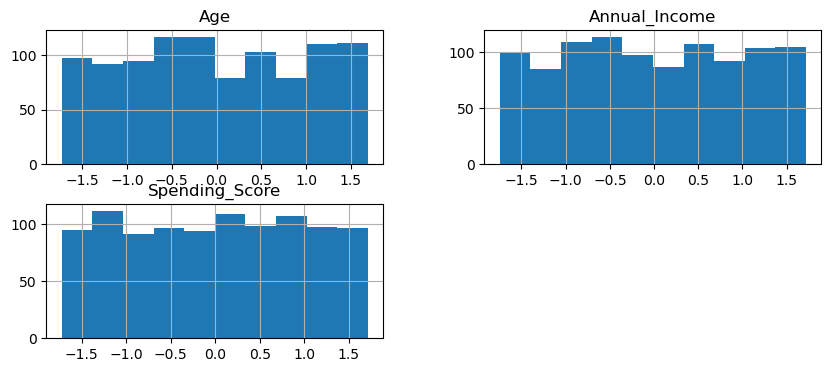

In [85]:
df_scaled[['Age', 'Annual_Income', 'Spending_Score']].hist(figsize=(10,4))


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Gender           1000 non-null   object
 1   City             1000 non-null   object
 2   Education_Level  1000 non-null   object
 3   Membership_Type  1000 non-null   object
 4   Payment_Method   1000 non-null   object
 5   Age              1000 non-null   int64 
 6   Annual_Income    1000 non-null   int64 
 7   Spending_Score   1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [87]:
df.head()

,Gender,City,Education_Level,Membership_Type,Payment_Method,Age,Annual_Income,Spending_Score
0,Male,Chennai,High School,Platinum,Net Banking,45,1134550,16
1,Female,Delhi,Master,Silver,UPI,22,782111,24
2,Male,Delhi,Master,Basic,Credit Card,22,733903,61
3,Male,Delhi,High School,Gold,Cash,38,706554,54
4,Male,Pune,Master,Gold,Cash,29,1116931,62


**Ordinal Encoding**

In [88]:
print(df['Education_Level'].unique())
print(df['Membership_Type'].unique())
print(df['Payment_Method'].unique())


['High School' 'Master' 'Bachelor' 'PhD']
['Platinum' 'Silver' 'Basic' 'Gold']
['Net Banking' 'UPI' 'Credit Card' 'Cash' 'Debit Card']


In [89]:
ordered_edu = {
    'High School': 1 ,
    'Bachelor': 2 ,
    'Master': 3 ,
    'PhD': 4
}
df['Education_Level_enc'] = df['Education_Level'].map(ordered_edu)

In [90]:
membership_order = {
    'Basic': 1,
    'Silver': 2,
    'Gold': 3,
    'Platinum': 4
}

df['Membership_Type_enc'] = df['Membership_Type'].map(membership_order)


**One Hot Encoding**

In [91]:
df_encoded = pd.get_dummies(
    df,
    columns=['Gender', 'City', 'Payment_Method'],
    drop_first=True
)
df_encoded.drop(
    columns=['Education_Level', 'Membership_Type'],
    inplace=True
)


In [92]:
df_encoded.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Age                         1000 non-null   int64
 1   Annual_Income               1000 non-null   int64
 2   Spending_Score              1000 non-null   int64
 3   Education_Level_enc         1000 non-null   int64
 4   Membership_Type_enc         1000 non-null   int64
 5   Gender_Male                 1000 non-null   bool 
 6   City_Chennai                1000 non-null   bool 
 7   City_Delhi                  1000 non-null   bool 
 8   City_Hyderabad              1000 non-null   bool 
 9   City_Mumbai                 1000 non-null   bool 
 10  City_Pune                   1000 non-null   bool 
 11  Payment_Method_Credit Card  1000 non-null   bool 
 12  Payment_Method_Debit Card   1000 non-null   bool 
 13  Payment_Method_Net Banking  1000 non-null   bool 
 14  Payment_M

In [93]:
df_encoded.head()

,Age,Annual_Income,Spending_Score,Education_Level_enc,Membership_Type_enc,Gender_Male,City_Chennai,City_Delhi,City_Hyderabad,City_Mumbai,City_Pune,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_Net Banking,Payment_Method_UPI
0,45,1134550,16,1,4,True,True,False,False,False,False,False,False,True,False
1,22,782111,24,3,2,False,False,True,False,False,False,False,False,False,True
2,22,733903,61,3,1,True,False,True,False,False,False,True,False,False,False
3,38,706554,54,1,3,True,False,True,False,False,False,False,False,False,False
4,29,1116931,62,3,3,True,False,False,False,False,True,False,False,False,False


In [94]:
df_encoded.to_csv(
    'datasets/customer_categorical_dataset_encoded.csv',
    index=False
)
